<a href="https://colab.research.google.com/github/narjes-sardouk1/Projet_ML/blob/main-ARS/Projet_ARS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***PARTIE 0  — Chargement & exploration des données***

In [ ]:
import gzip
import shutil

# nom du fichier compressé
gz_file = "facebook_combined.txt.gz"

# nom du fichier décompressé
txt_file = "facebook_combined.txt"

# décompression
with gzip.open(gz_file, 'rb') as f_in:
    with open(txt_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Décompression réussie :", txt_file)

Décompression réussie : facebook_combined.txt


Ce code transforme le fichier compressé facebook_combined en fichier texte utilisable pour l’analyse de réseau

In [ ]:
from google.colab import files  # importe le module files depuis Google Colab pour permettre le téléversement de fichiers

# Ouvre une fenêtre pour choisir un fichier depuis ton PC
uploaded = files.upload()  # lance une interface qui permet de sélectionner et uploader un fichier depuis l’ordinateur vers l’environnement Colab

# nouvelle ligne : on récupère et force le nom attendu
file_name = "facebook_combined.txt"

print("Upload réussi" if uploaded else "Aucun fichier uploadé")  # vérifie si un fichier a été uploadé et affiche un message de succès ou d’échec

Saving facebook_combined.txt.gz to facebook_combined.txt.gz
Upload réussi


ce code permet de charger le fichier local dans Colab et vérifier son importation pour l’analyse de données (ARS).

In [ ]:
import networkx as nx  # importe la bibliothèque NetworkX pour la création et l’analyse de graphes

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)
# lit le fichier et construit un graphe où chaque ligne représente une relation entre deux utilisateurs

# afficher les informations sur la structure du réseau
print(" Structure du dataset initial \n ")
# affiche un titre pour présenter les informations du dataset

# Réseau uni-parti vs multi-parti
print(" Type de réseau (uni-parti / multi-parti)")
# affiche la classification du type de réseau

print(" Réseau uni-parti :Tous les nœuds sont du même type : utilisateurs Facebook + Les liens représentent une seule relation : amitié \n")
# indique que le réseau est uni-parti car tous les nœuds sont des utilisateurs et une seule relation existe

#  Orienté vs non orienté
print(" Nature du réseau")
# affiche la section sur l’orientation du réseau

if nx.is_directed(G):
    # vérifie si le graphe est orienté ou non
    print(" Réseau orienté")
    # affiche si le réseau est orienté
else:
    print(" Réseau non orienté (amitié symétrique)\n")
    # indique que les relations sont bidirectionnelles (amitié réciproque)

print("\nVolume du réseau :")
# affiche la section sur la taille du réseau

print("Nombre de nœuds :", G.number_of_nodes())
# affiche le nombre total d’utilisateurs (nœuds)

print("Nombre d'arêtes :", G.number_of_edges())
# affiche le nombre total de relations (liens)

 Structure du dataset initial 
 
 Type de réseau (uni-parti / multi-parti)
 Réseau uni-parti :Tous les nœuds sont du même type : utilisateurs Facebook + Les liens représentent une seule relation : amitié 

 Nature du réseau
 Réseau non orienté (amitié symétrique)


Volume du réseau :
Nombre de nœuds : 4039
Nombre d'arêtes : 88234



Ce bloc de code réalise une description globale de la structure du dataset représentant le réseau Facebook Combined. Les données sont organisées sous forme de liste d’arêtes, où chaque ligne contient deux identifiants séparés par un espace:
 - un nœud représente un utilisateur et
- une arête représente une relation d’amitié entre deux utilisateurs.

Le réseau est de type uni-parti, car tous les nœuds correspondent à des utilisateurs Facebook et une seule catégorie de relation est considérée. Il s’agit également d’un réseau non orienté, puisque les relations d’amitié sont réciproques.

- **Le réseau contient 4039 utilisateurs (nœuds) et 88 234 relations (arêtes), ce qui montre un réseau social très dense avec de nombreuses connexions entre les individus.**


In [ ]:
import networkx as nx
import pandas as pd

# Charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# Transformer en DataFrame
df = pd.DataFrame(list(G.edges()), columns=["source", "target"])

# Réinitialiser l'index pour avoir une colonne propre
df = df.reset_index()

# Affichage type tableau
display(df)

,index,source,target
0,0,0,1
1,1,0,2
2,2,0,3
3,3,0,4
4,4,0,5
...,...,...,...
88229,88229,4023,4034
88230,88230,4023,4038
88231,88231,4026,4030
88232,88232,4027,4032


Ce bloc transforme le réseau en tableau structuré avec 3 colonnes : index (numéro de ligne), source (nœud de départ) et target (nœud d'arrivée). Le tableau contient 88 234 lignes, chaque ligne représentant un lien entre deux utilisateurs Facebook. Cette représentation en DataFrame pandas est utile pour manipuler, filtrer et analyser les données du réseau par la suite.

Nombre de nœuds : 4039
Nombre d'arêtes : 88234


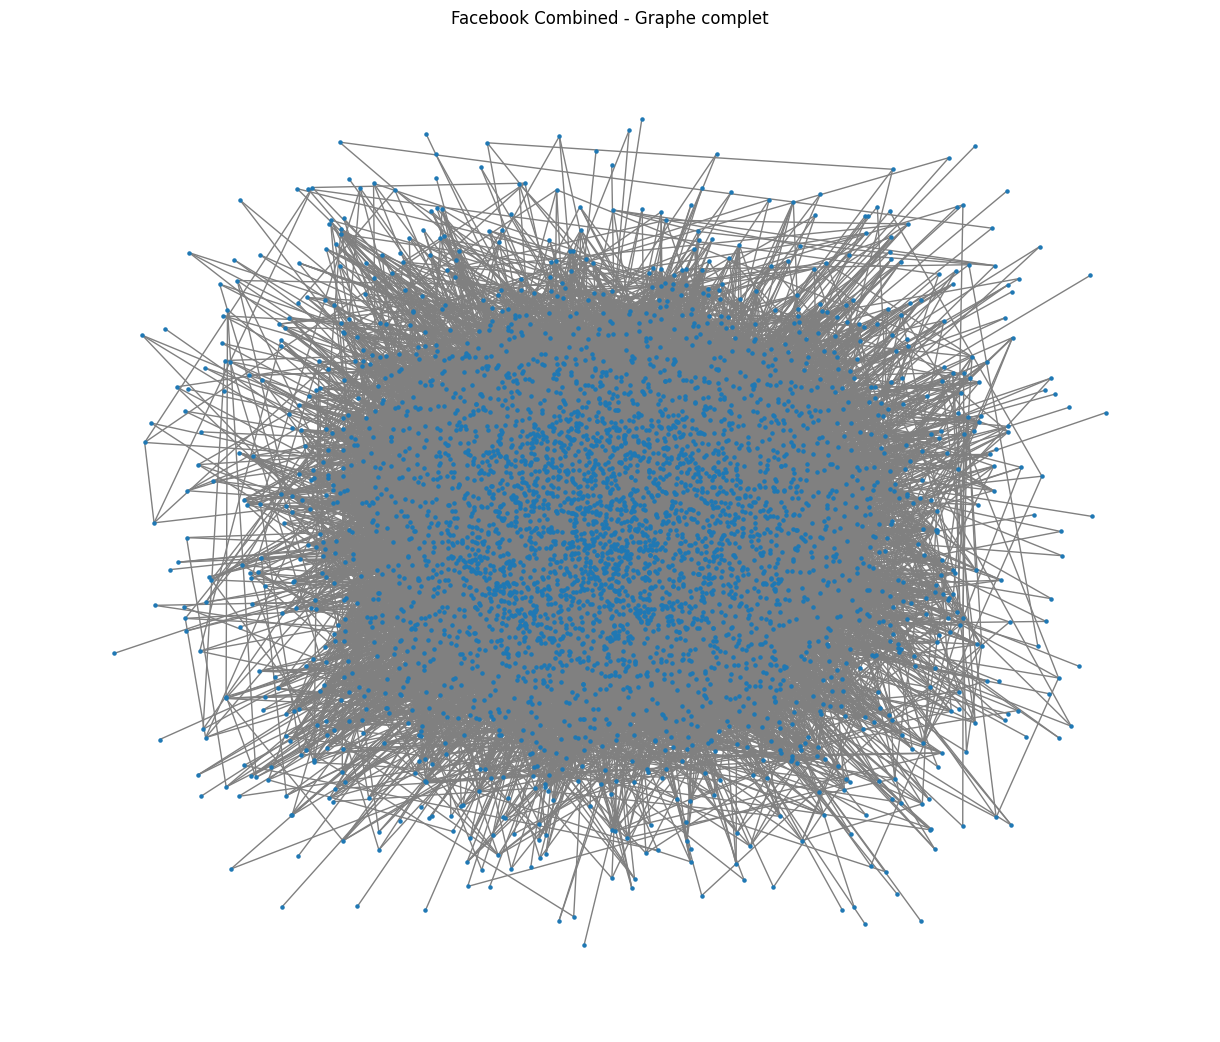

In [ ]:
import networkx as nx  # bibliothèque pour manipuler les graphes
import matplotlib.pyplot as plt

%matplotlib inline

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# afficher les statistiques du réseau
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d'arêtes :", G.number_of_edges())

# affichage du graphe
plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.05, iterations=10)

nx.draw(G, pos,
        node_size=5,
        edge_color="gray",  # couleur des liens
        with_labels=False)

plt.title("Facebook Combined - Graphe complet")
plt.show()

Ce code permet de visualiser le réseau Facebook complet à partir du fichier *facebook_combined.txt*. Il met en évidence que le graphe contient **4039 nœuds (utilisateurs)** et **88 234 liens (relations)**, ce qui représente un réseau très dense. Lorsqu’il est affiché tel quel, le graphe devient difficilement lisible à cause du grand nombre de connexions qui se chevauchent. Pour cette raison, **un filtrage par densité a été appliqué afin de conserver uniquement les nœuds ayant plus de 20 connexions**, ce qui permet de réduire la complexité du réseau et d’obtenir une visualisation plus claire et exploitable.


***PARTIE 1: NETTOYAGE DE DONNEES***

Après filtrage (degré > 20)
Nombre de nœuds : 2278
Nombre de liens : 74273


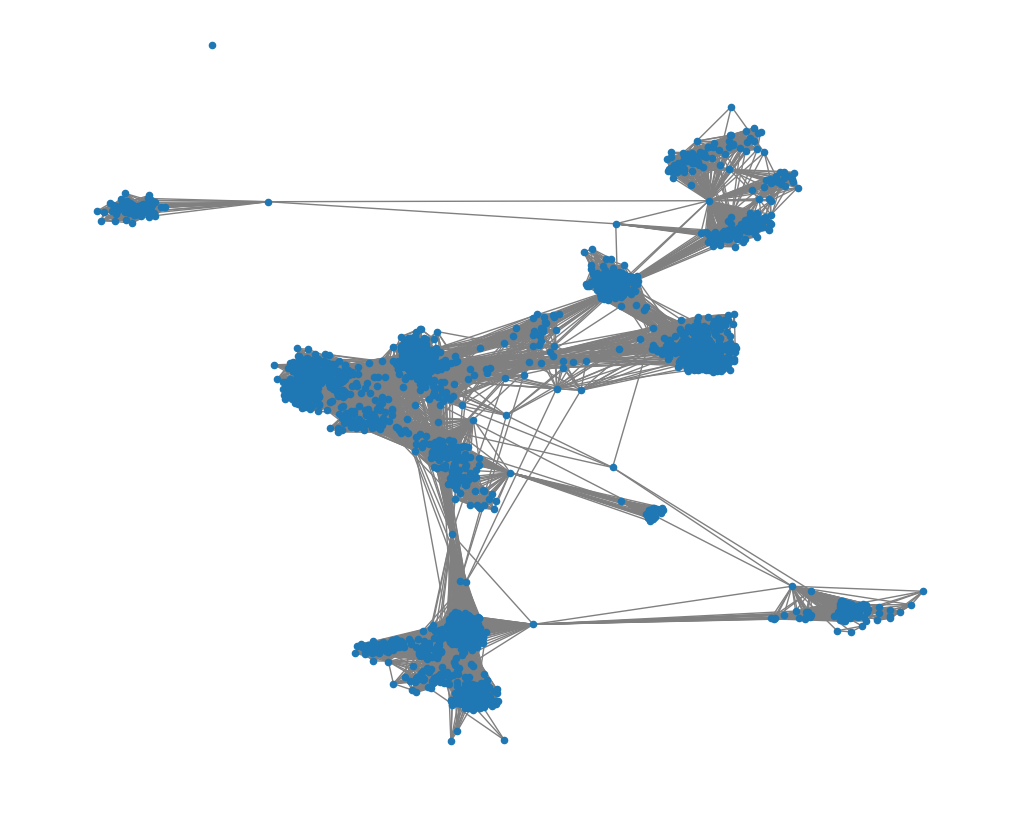

In [ ]:
import networkx as nx  # importe la bibliothèque NetworkX pour créer et analyser des graphes
%matplotlib inline
import matplotlib.pyplot as plt  # importe matplotlib pour la visualisation des graphes

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)
# lit le fichier et crée un graphe où les nœuds sont des entiers (utilisateurs)

# garder seulement les nœuds avec un degré > seuil
threshold = 20
# définit un seuil minimum de connexions (degré) pour filtrer les nœuds

nodes_filtered = [n for n in G.nodes() if G.degree(n) > threshold]
# sélectionne uniquement les nœuds ayant plus de 20 connexions

# sous-graphe filtré
H = G.subgraph(nodes_filtered)
# crée un nouveau graphe contenant uniquement les nœuds filtrés

# afficher les statistiques après nettoyage
print("Après filtrage (degré > 20)")
print("Nombre de nœuds :", H.number_of_nodes())
print("Nombre de liens :", H.number_of_edges())

# affichage
plt.figure(figsize=(10,8))
# définit la taille de la figure (largeur, hauteur)

pos = nx.spring_layout(H, k=0.2)
# calcule la position des nœuds pour un affichage clair et organisé

nx.draw(H, pos, node_size=20, edge_color="gray", with_labels=False)
# dessine le graphe avec petits nœuds, arêtes grises et sans labels

plt.show()
# affiche le graphe à l'écran

Après filtrage, le réseau Facebook ne contient plus que **2278 nœuds** et **74 273 liens**. Cela signifie que seuls les utilisateurs ayant plus de 20 connexions ont été conservés. Ce filtrage réduit la complexité du graphe en éliminant les nœuds peu connectés, ce qui améliore sa lisibilité. Le réseau obtenu met ainsi en évidence les utilisateurs les plus actifs et les plus connectés, facilitant l’analyse de la structure globale et des interactions importantes au sein du réseau.


*Analyse du réseau*

***PARTIE 3: ANALYSE DU RESEAU: CALCUL DES METRIQUES DE CENTRALITES***

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul des degrés
degrees = dict(G.degree())

# afficher quelques exemples
print("Exemples de degrés :")
for i, (node, deg) in enumerate(degrees.items()):
    if i < 10:
        print(f"Nœud {node} → degré = {deg}")


Exemples de degrés :
Nœud 0 → degré = 347
Nœud 1 → degré = 17
Nœud 2 → degré = 10
Nœud 3 → degré = 17
Nœud 4 → degré = 10
Nœud 5 → degré = 13
Nœud 6 → degré = 6
Nœud 7 → degré = 20
Nœud 8 → degré = 8
Nœud 9 → degré = 57


Ce bloc de code charge le réseau Facebook complet depuis facebook_combined.txt, calcule le degré de chaque nœud (c'est-à-dire le nombre de connexions de chaque personne), puis affiche les 10 premiers résultats.

On observe que:
- Le nœud 0 est clairement un hub majeur avec 347 connexions, c'est l'un des acteurs les plus influents du réseau, probablement un nœud principal qui concentre énormément de relations autour de lui.

- Le nœud 9 avec 57 connexions est également un acteur bien connecté, au-dessus de la moyenne, jouant un rôle intermédiaire important dans la circulation de l'information.

- Les nœuds 1, 3, 5, 7 entre 13 et 20 connexions représentent des acteurs ordinaires, ni isolés ni dominants.

- Les nœuds 2, 4, 6, 8 avec entre 6 et 10 connexions sont des acteurs périphériques, peu connectés, dépendants des nœuds mieux connectés pour accéder au reste du réseau.

In [ ]:
import numpy as np

# calcul de la moyenne des degrés
degrees = dict(G.degree())
# récupère le dictionnaire {nœud: degré} depuis le graphe

valeurs_degres = list(degrees.values())
# extrait uniquement les valeurs de degrés sous forme de liste

moyenne = np.mean(valeurs_degres)
# calcule la moyenne arithmétique de tous les degrés

print(f"degré moyen : {moyenne:.2f}")
# affiche la moyenne avec 2 décimales

degré moyen : 43.69


La moyenne des degrés représente le nombre moyen de connexions que possède chaque acteur dans le réseau. Pour le réseau Facebook, une moyenne de 43.69 signifie qu'en moyenne chaque personne est connectée à environ 44 autres personnes.

In [ ]:
# tri décroissant
top_degree = sorted(G.degree(), key=lambda x: x[1], reverse=True)

print("Top 10 des nœuds avec le plus grand degré :")
for node, val in top_degree[:10]:
    print(f"Nœud {node} → degré = {val}")

Top 10 des nœuds avec le plus grand degré :
Nœud 107 → degré = 1045
Nœud 1684 → degré = 792
Nœud 1912 → degré = 755
Nœud 3437 → degré = 547
Nœud 0 → degré = 347
Nœud 2543 → degré = 294
Nœud 2347 → degré = 291
Nœud 1888 → degré = 254
Nœud 1800 → degré = 245
Nœud 1663 → degré = 235


Ce bloc trie les nœuds par degré décroissant et affiche les 10 plus connectés. Le nœud 107 domine avec 1045 connexions, suivi des autres egos principaux du dataset (1684, 1912, 3437). Ces 10 nœuds ont tous un degré bien supérieur à la moyenne (43.69), confirmant leur rôle de hubs centraux dans le réseau.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul de la centralité de degré
deg_centrality = nx.degree_centrality(G)

# afficher quelques exemples
print("Exemples de centralité de degré :")
for i, (node, cent) in enumerate(deg_centrality.items()):
    if i < 10:
        print(f"Nœud {node} → centralité = {cent:.5f}")


Exemples de centralité de degré :
Nœud 0 → centralité = 0.08593
Nœud 1 → centralité = 0.00421
Nœud 2 → centralité = 0.00248
Nœud 3 → centralité = 0.00421
Nœud 4 → centralité = 0.00248
Nœud 5 → centralité = 0.00322
Nœud 6 → centralité = 0.00149
Nœud 7 → centralité = 0.00495
Nœud 8 → centralité = 0.00198
Nœud 9 → centralité = 0.01412


Ce bloc calcule la centralité de degré de chaque nœud, c'est-à-dire l'importance d'un nœud dans le réseau basée sur son nombre de connexions(liens). Le nœud 0 avec 0.086 est le plus central des 10, il est connecté à environ 8.6% de l'ensemble du réseau. Les autres nœuds affichent des valeurs très faibles (entre 0.001 et 0.014), ce qui confirme qu'ils ne sont connectés qu'à une très petite partie du réseau et occupent donc une position périphérique.

In [ ]:
# tri décroissant
top_deg_centrality = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)

print("Top 10 des nœuds les plus centraux (degree centrality) :")
for node, val in top_deg_centrality[:10]:
    print(f"Nœud {node} → centralité = {val:.5f}")

Top 10 des nœuds les plus centraux (degree centrality) :
Nœud 107 → centralité = 0.25879
Nœud 1684 → centralité = 0.19614
Nœud 1912 → centralité = 0.18697
Nœud 3437 → centralité = 0.13546
Nœud 0 → centralité = 0.08593
Nœud 2543 → centralité = 0.07281
Nœud 2347 → centralité = 0.07207
Nœud 1888 → centralité = 0.06290
Nœud 1800 → centralité = 0.06067
Nœud 1663 → centralité = 0.05820


Ce bloc trie tous les nœuds par centralité de degré décroissante et affiche les 10 plus centraux. Le nœud 107 domine avec une centralité de 0.259, ce qui signifie qu'il est directement connecté à environ **26% de l'ensemble du réseau** ,  c'est l'acteur le plus influent. Les nœuds 1684, 1912 et 3437 suivent avec respectivement 19.6%, 18.7% et 13.5%, confirmant leur rôle de hubs principaux. À partir du nœud 0 (8.6%), les valeurs descendent progressivement vers 5.8%, restant tout de même bien au-dessus de la moyenne, ce qui confirme que ces 10 acteurs constituent le cœur décisionnel du réseau autour duquel s'organisent les connexions de la majorité des acteurs périphériques.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul de la closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# afficher quelques exemples
print("Exemples de closeness centrality :")
for i, (node, cent) in enumerate(closeness_centrality.items()):
    if i < 10:
        print(f"Nœud {node} → centralité = {cent:.5f}")

Exemples de closeness centrality :
Nœud 0 → centralité = 0.35334
Nœud 1 → centralité = 0.26138
Nœud 2 → centralité = 0.26126
Nœud 3 → centralité = 0.26138
Nœud 4 → centralité = 0.26126
Nœud 5 → centralité = 0.26131
Nœud 6 → centralité = 0.26119
Nœud 7 → centralité = 0.27477
Nœud 8 → centralité = 0.26122
Nœud 9 → centralité = 0.26205


Ce bloc calcule la closeness centrality de chaque nœud, c'est-à-dire à quel point un acteur est proche de tous les autres dans le réseau. Le nœud 0 avec une valeur de **0.353** est le plus central des 10, il est structurellement le plus proche de l'ensemble des autres acteurs et peut diffuser une information plus rapidement que les autres. Les nœuds 1 à 9 ont des valeurs très proches autour de **0.261**, ce qui indique qu'ils occupent tous une position similaire et assez éloignée du centre du réseau, nécessitant plus d'intermédiaires pour atteindre l'ensemble des acteurs.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul de la closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# trier les nœuds du plus central au moins central
top_10 = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 closeness centrality :")
for node, cent in top_10:
    print(f"Nœud {node} → centralité = {cent:.5f}")

Top 10 closeness centrality :
Nœud 107 → centralité = 0.45970
Nœud 58 → centralité = 0.39740
Nœud 428 → centralité = 0.39484
Nœud 563 → centralité = 0.39391
Nœud 1684 → centralité = 0.39361
Nœud 171 → centralité = 0.37049
Nœud 348 → centralité = 0.36992
Nœud 483 → centralité = 0.36985
Nœud 414 → centralité = 0.36954
Nœud 376 → centralité = 0.36656


Ce bloc affiche les 10 nœuds les plus proches structurellement de l'ensemble du réseau. Le nœud 107 domine avec une closeness de **0.460** ,  c'est l'acteur le plus rapide pour atteindre n'importe qui dans le réseau, confirmant son rôle de noeud central du dataset.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul de la betweenness centrality
betweenness = nx.betweenness_centrality(G)

# afficher quelques résultats
print("Exemples de betweenness centrality :")
for i, (node, val) in enumerate(betweenness.items()):
    if i < 10:
        print(f"Nœud {node} → betweenness = {val:.6f}")

Exemples de betweenness centrality :
Nœud 0 → betweenness = 0.146306
Nœud 1 → betweenness = 0.000003
Nœud 2 → betweenness = 0.000000
Nœud 3 → betweenness = 0.000002
Nœud 4 → betweenness = 0.000000
Nœud 5 → betweenness = 0.000002
Nœud 6 → betweenness = 0.000000
Nœud 7 → betweenness = 0.000170
Nœud 8 → betweenness = 0.000000
Nœud 9 → betweenness = 0.000016


Ce bloc calcule la betweenness centrality de chaque nœud, c'est-à-dire la proportion des plus courts chemins du réseau qui passent par ce nœud. Le nœud 0 avec une valeur de 0.146 se distingue nettement des autres avec environ **14.6% de tous les chemins** du réseau qui transitent par lui, ce qui en fait un **point de passage obligatoire** pour la circulation de l'information. Les nœuds 2, 4, 6 et 8 avec une valeur de 0.000000 ne se trouvent sur aucun chemin entre deux autres acteurs, ils sont complètement transparents structurellement et n'ont aucun rôle d'intermédiaire dans le réseau.

In [ ]:
# tri décroissant
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

print("Top 10 des nœuds les plus importants (betweenness) :")
for node, val in top_betweenness[:10]:
    print(f"Nœud {node} → betweenness = {val:.6f}")

Top 10 des nœuds les plus importants (betweenness) :
Nœud 107 → betweenness = 0.480518
Nœud 1684 → betweenness = 0.337797
Nœud 3437 → betweenness = 0.236115
Nœud 1912 → betweenness = 0.229295
Nœud 1085 → betweenness = 0.149015
Nœud 0 → betweenness = 0.146306
Nœud 698 → betweenness = 0.115330
Nœud 567 → betweenness = 0.096310
Nœud 58 → betweenness = 0.084360
Nœud 428 → betweenness = 0.064309


Ce bloc trie tous les nœuds par betweenness centrality décroissante et affiche les 10 plus importants. Le nœud 107 domine avec 0.481, près de **48% de tous les chemins** du réseau passent par lui, ce qui en fait le principal pont de communication du réseau. Les nœuds 1684, 3437 et 1912 suivent avec respectivement 33.8%, 23.6% et 22.9%, confirmant leur rôle d'intermédiaires majeurs. Ces 4 nœuds correspondent aux egos principaux du dataset, ce qui explique leur position stratégique. À partir du nœud 1085 (14.9%), les valeurs descendent progressivement vers 6.4%, restant tout de même très élevées, la suppression de l'un de ces 10 nœuds fragmenterait considérablement le réseau et isolerait de nombreux acteurs périphériques.

In [ ]:
import networkx as nx
import pandas as pd

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# mesures
degree = dict(G.degree())
deg_cent = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G)

# dataframe
df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()]
})

# normalisation simple (pour comparer)
df["score_global"] = (
    df["degree_centrality"] +
    df["closeness"] +
    df["betweenness"]
)

# tri
best_node = df.sort_values(by="score_global", ascending=False).head(1)

print("=== NŒUD LE PLUS CENTRAL GLOBAL ===")
print(best_node)

=== NŒUD LE PLUS CENTRAL GLOBAL ===
     node  degree  degree_centrality  closeness  betweenness  score_global
107   107    1045           0.258791   0.459699     0.480518      1.199009


Ce bloc calcule un **score global de centralité** en combinant les 3 mesures (degré, closeness, betweenness) pour chaque nœud, puis identifie le nœud le plus central du réseau. Le nœud **107** domine sur les 3 dimensions simultanément avec un score global de **1.199** , **il est à la fois le plus connecté (degré = 1045), le plus proche de tout le réseau (closeness = 0.460) et le plus stratégique comme intermédiaire (betweenness = 0.481)**. Ce résultat confirme que le nœud 107 est l'acteur **le plus influent** du réseau Facebook sous tous les angles d'analyse, il concentre le pouvoir relationnel, diffuse l'information le plus rapidement et contrôle les flux de communication entre les différentes communautés du réseau.

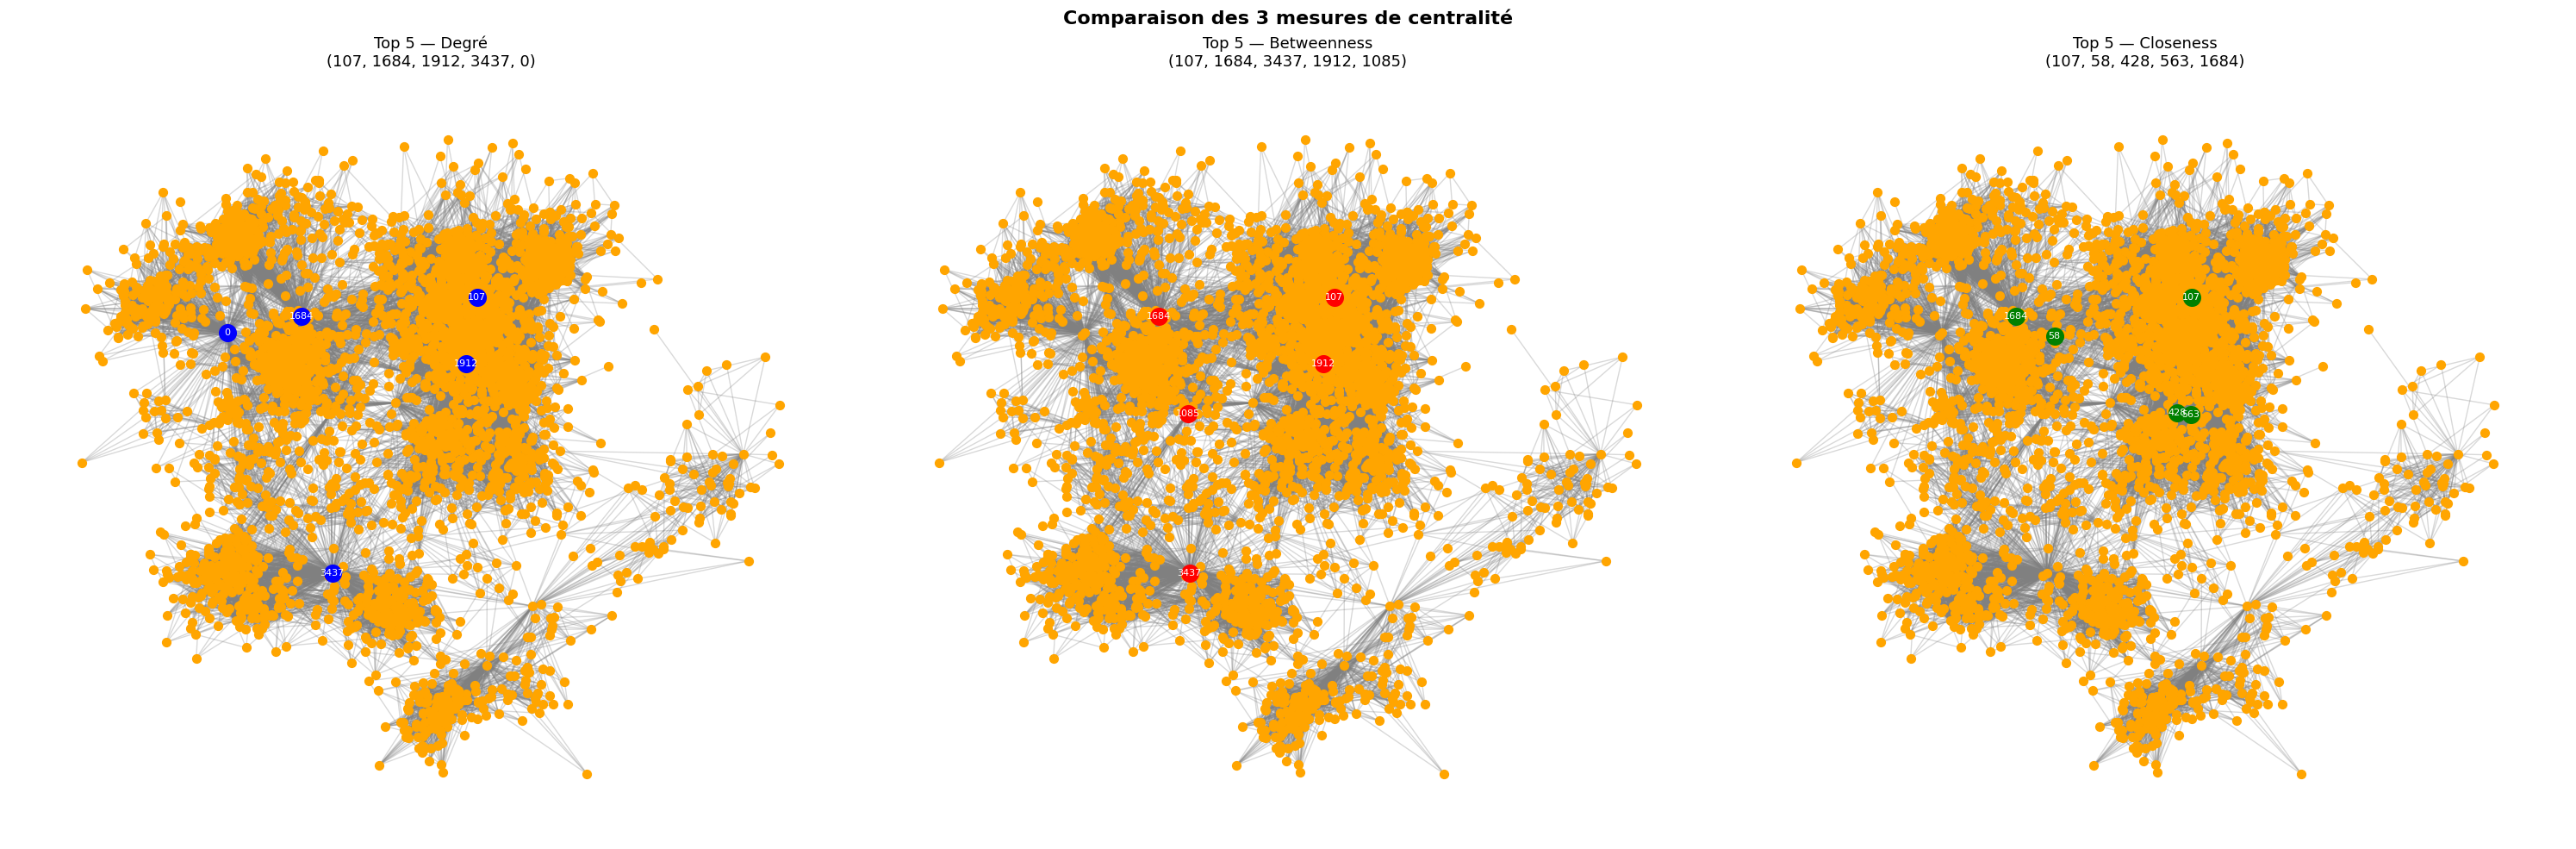

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# Position des nœuds (calculée une seule fois pour les 3 graphiques)
pos = nx.spring_layout(G, seed=42)
# seed=42 garantit la même disposition pour les 3 visualisations

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
# crée 3 graphiques côte à côte

# ── Graphique 1 : Top 5 degré ────────────────────────────────────
top_degree = [107, 1684, 1912, 3437, 0]
# les 5 nœuds avec le plus grand nombre de connexions

nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color="orange", node_size=50)
# tous les nœuds en orange
nx.draw_networkx_nodes(G, pos, ax=axes[0], nodelist=top_degree,
                       node_color="blue", node_size=200)
# les 5 hubs en bleu
nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.3, edge_color="gray")
# liens en gris transparent
nx.draw_networkx_labels(G, pos, ax=axes[0],
                        labels={n: n for n in top_degree},
                        font_size=8, font_color="white")
# affiche uniquement les labels des 5 nœuds importants
axes[0].set_title("Top 5 — Degré\n(107, 1684, 1912, 3437, 0)", fontsize=13)
axes[0].axis("off")

# ── Graphique 2 : Top 5 betweenness ─────────────────────────────
top_betweenness = [107, 1684, 3437, 1912, 1085]
# les 5 nœuds les plus stratégiques (intermédiaires)

nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color="orange", node_size=50)
# tous les nœuds en orange
nx.draw_networkx_nodes(G, pos, ax=axes[1], nodelist=top_betweenness,
                       node_color="red", node_size=200)
# les 5 intermédiaires en rouge
nx.draw_networkx_edges(G, pos, ax=axes[1], alpha=0.3, edge_color="gray")
# liens en gris transparent
nx.draw_networkx_labels(G, pos, ax=axes[1],
                        labels={n: n for n in top_betweenness},
                        font_size=8, font_color="white")
# affiche uniquement les labels des 5 nœuds importants
axes[1].set_title("Top 5 — Betweenness\n(107, 1684, 3437, 1912, 1085)", fontsize=13)
axes[1].axis("off")

# ── Graphique 3 : Top 5 closeness ───────────────────────────────
top_closeness = [107, 58, 428, 563, 1684]
# les 5 nœuds les plus proches structurellement de tout le réseau

nx.draw_networkx_nodes(G, pos, ax=axes[2], node_color="orange", node_size=50)
# tous les nœuds en orange
nx.draw_networkx_nodes(G, pos, ax=axes[2], nodelist=top_closeness,
                       node_color="green", node_size=200)
# les 5 nœuds les plus proches en vert
nx.draw_networkx_edges(G, pos, ax=axes[2], alpha=0.3, edge_color="gray")
# liens en gris transparent
nx.draw_networkx_labels(G, pos, ax=axes[2],
                        labels={n: n for n in top_closeness},
                        font_size=8, font_color="white")
# affiche uniquement les labels des 5 nœuds importants
axes[2].set_title("Top 5 — Closeness\n(107, 58, 428, 563, 1684)", fontsize=13)
axes[2].axis("off")

plt.suptitle("Comparaison des 3 mesures de centralité", fontsize=16, fontweight="bold")
# titre général pour les 3 graphiques
plt.tight_layout()
plt.savefig("centralites_comparaison.png", dpi=150, bbox_inches="tight")
# enregistre les 3 graphiques en un seul fichier PNG
plt.show()

Ce bloc produit 3 visualisations côte à côte comparant les 3 mesures de centralité sur le même réseau avec la même disposition des nœuds.

**Graphique 1 (bleu — degré)** montre les 5 nœuds les plus connectés (107, 1684, 1912, 3437, 0). Ces hubs apparaissent au centre du graphe entourés d'un grand nombre de liens, confirmant leur rôle de points de concentration des connexions.

**Graphique 2 (rouge — betweenness)** met en évidence les 5 nœuds les plus stratégiques (107, 1684, 3437, 1912, 1085). Ils se situent sur les chemins reliant différentes parties du réseau, ce sont les **ponts** entre communautés, dont la suppression fragmenterait le réseau.

**Graphique 3 (vert — closeness)** identifie les 5 nœuds structurellement les plus proches de tout le réseau (107, 58, 428, 563, 1684). Contrairement aux deux autres mesures, on remarque l'apparition de nouveaux nœuds (58, 428, 563) qui ne figuraient pas dans le top degré ni betweenness, montrant qu'un acteur peut être très proche de tout le réseau sans forcément être très connecté ou très intermédiaire.

La comparaison des 3 graphiques révèle que le nœud **107 et 1684** dominent les 3 mesures simultanément, ce sont les acteurs les plus influents sous tous les angles structurels du réseau.

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# coefficient de clustering local (pour chaque nœud)
clustering_local = nx.clustering(G)

# afficher quelques exemples
print("Exemples de clustering local :")
for i, (node, val) in enumerate(clustering_local.items()):
    if i < 10:
        print(f"Nœud {node} → clustering local = {val:.5f}")

Exemples de clustering local :
Nœud 0 → clustering local = 0.04196
Nœud 1 → clustering local = 0.41912
Nœud 2 → clustering local = 0.88889
Nœud 3 → clustering local = 0.63235
Nœud 4 → clustering local = 0.86667
Nœud 5 → clustering local = 0.33333
Nœud 6 → clustering local = 0.93333
Nœud 7 → clustering local = 0.43158
Nœud 8 → clustering local = 0.67857
Nœud 9 → clustering local = 0.39724


Ce bloc calcule le coefficient de clustering local de chaque nœud, c'est-à-dire la proportion de ses voisins qui sont également connectés entre eux. Le nœud 6 avec 0.933 est le plus fort, presque tous ses voisins se connaissent entre eux, il appartient donc à un groupe très soudé. À l'opposé, le nœud 0 avec seulement 0.042 a très peu de voisins interconnectés malgré ses 347 connexions, ce qui est typique des hubs : plus un nœud est connecté à beaucoup de personnes, moins ces personnes ont tendance à se connaître entre elles car elles proviennent de cercles sociaux différents.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# clustering local (par nœud)
clustering_local = nx.clustering(G)

# tri décroissant
top_clustering_local = sorted(clustering_local.items(), key=lambda x: x[1], reverse=True)

print("Top 10 des nœuds avec le plus fort clustering local :")
for node, val in top_clustering_local[:10]:
    print(f"Nœud {node} → clustering local = {val:.5f}")

Top 10 des nœuds avec le plus fort clustering local :
Nœud 32 → clustering local = 1.00000
Nœud 33 → clustering local = 1.00000
Nœud 35 → clustering local = 1.00000
Nœud 42 → clustering local = 1.00000
Nœud 44 → clustering local = 1.00000
Nœud 46 → clustering local = 1.00000
Nœud 47 → clustering local = 1.00000
Nœud 52 → clustering local = 1.00000
Nœud 63 → clustering local = 1.00000
Nœud 70 → clustering local = 1.00000


Ce bloc trie tous les nœuds par coefficient de clustering décroissant et affiche les 10 premiers. Ces 10 nœuds ont tous un clustering local de **1.0**, ce qui signifie que **100% de leurs voisins se connaissent entre eux** ,  ils appartiennent à des cliques parfaites où tout le monde est connecté à tout le monde. C'est typique des petits cercles d'amis très soudés sur Facebook (famille, collègues proches, camarades de classe) où chaque membre du groupe connaît tous les autres membres. Ces nœuds sont donc structurellement très intégrés dans leur communauté locale, même s'ils peuvent avoir peu de connexions en dehors de ce cercle fermé.

In [ ]:
import networkx as nx

# charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# proximité: distance moyenne par nœud
avg_distance = {}

for node in G.nodes():
    lengths = nx.single_source_shortest_path_length(G, node)
    avg_distance[node] = sum(lengths.values()) / len(lengths)

# afficher quelques résultats
print("Exemples de distances moyennes :")
for i, (node, val) in enumerate(avg_distance.items()):
    if i < 10:
        print(f"Nœud {node} → distance moyenne = {val:.5f}")

Exemples de distances moyennes :
Nœud 0 → distance moyenne = 2.82941
Nœud 1 → distance moyenne = 3.82496
Nœud 2 → distance moyenne = 3.82669
Nœud 3 → distance moyenne = 3.82496
Nœud 4 → distance moyenne = 3.82669
Nœud 5 → distance moyenne = 3.82595
Nœud 6 → distance moyenne = 3.82768
Nœud 7 → distance moyenne = 3.63852
Nœud 8 → distance moyenne = 3.82718
Nœud 9 → distance moyenne = 3.81505


Ce bloc calcule la distance moyenne de chaque nœud vers tous les autres nœuds du réseau qui mesure à quel point ce nœud est proche du reste du réseau en général. Le nœud 0 avec une distance moyenne de 2.83 est le plus proche de l'ensemble du réseau, il peut atteindre n'importe quel acteur en passant par moins de 3 intermédiaires en moyenne, ce qui confirme son rôle de hub central. Les autres nœuds tournent autour de 3.82, ce qui signifie qu'ils ont besoin d'environ 4 intermédiaires pour atteindre n'importe qui dans le réseau.

In [ ]:
# calcul des distances moyennes par nœud
avg_dist = {}

for node in G.nodes():
    lengths = nx.single_source_shortest_path_length(G, node)
    avg_dist[node] = sum(lengths.values()) / len(lengths)

# tri décroissant
top_avg_dist = sorted(avg_dist.items(), key=lambda x: x[1], reverse=True)

print("Top 10 des nœuds avec la plus grande distance moyenne :")
for node, val in top_avg_dist[:10]:
    print(f"Nœud {node} → distance moyenne = {val:.5f}")

Top 10 des nœuds avec la plus grande distance moyenne :
Nœud 692 → distance moyenne = 5.60857
Nœud 801 → distance moyenne = 5.60857
Nœud 699 → distance moyenne = 5.60832
Nœud 744 → distance moyenne = 5.60832
Nœud 749 → distance moyenne = 5.60832
Nœud 750 → distance moyenne = 5.60832
Nœud 775 → distance moyenne = 5.60832
Nœud 841 → distance moyenne = 5.60832
Nœud 743 → distance moyenne = 5.60807
Nœud 785 → distance moyenne = 5.60807


Ce bloc trie les nœuds par distance moyenne décroissante et affiche les 10 les plus éloignés du reste du réseau. Ces 10 nœuds ont tous une distance moyenne d'environ **5.6**, ce qui signifie qu'ils ont besoin de presque 6 intermédiaires en moyenne pour atteindre n'importe quel autre acteur, ce sont les nœuds les plus **périphériques et isolés** du réseau. Comparés au nœud 0 (distance moyenne de 2.83), ils sont presque **deux fois plus éloignés** du centre du réseau, ce qui les rend lents à recevoir ou diffuser de l'information et fortement dépendants des hubs pour communiquer avec le reste du réseau.

Plus court chemin entre 107 et 1684 :
[107, 1684]


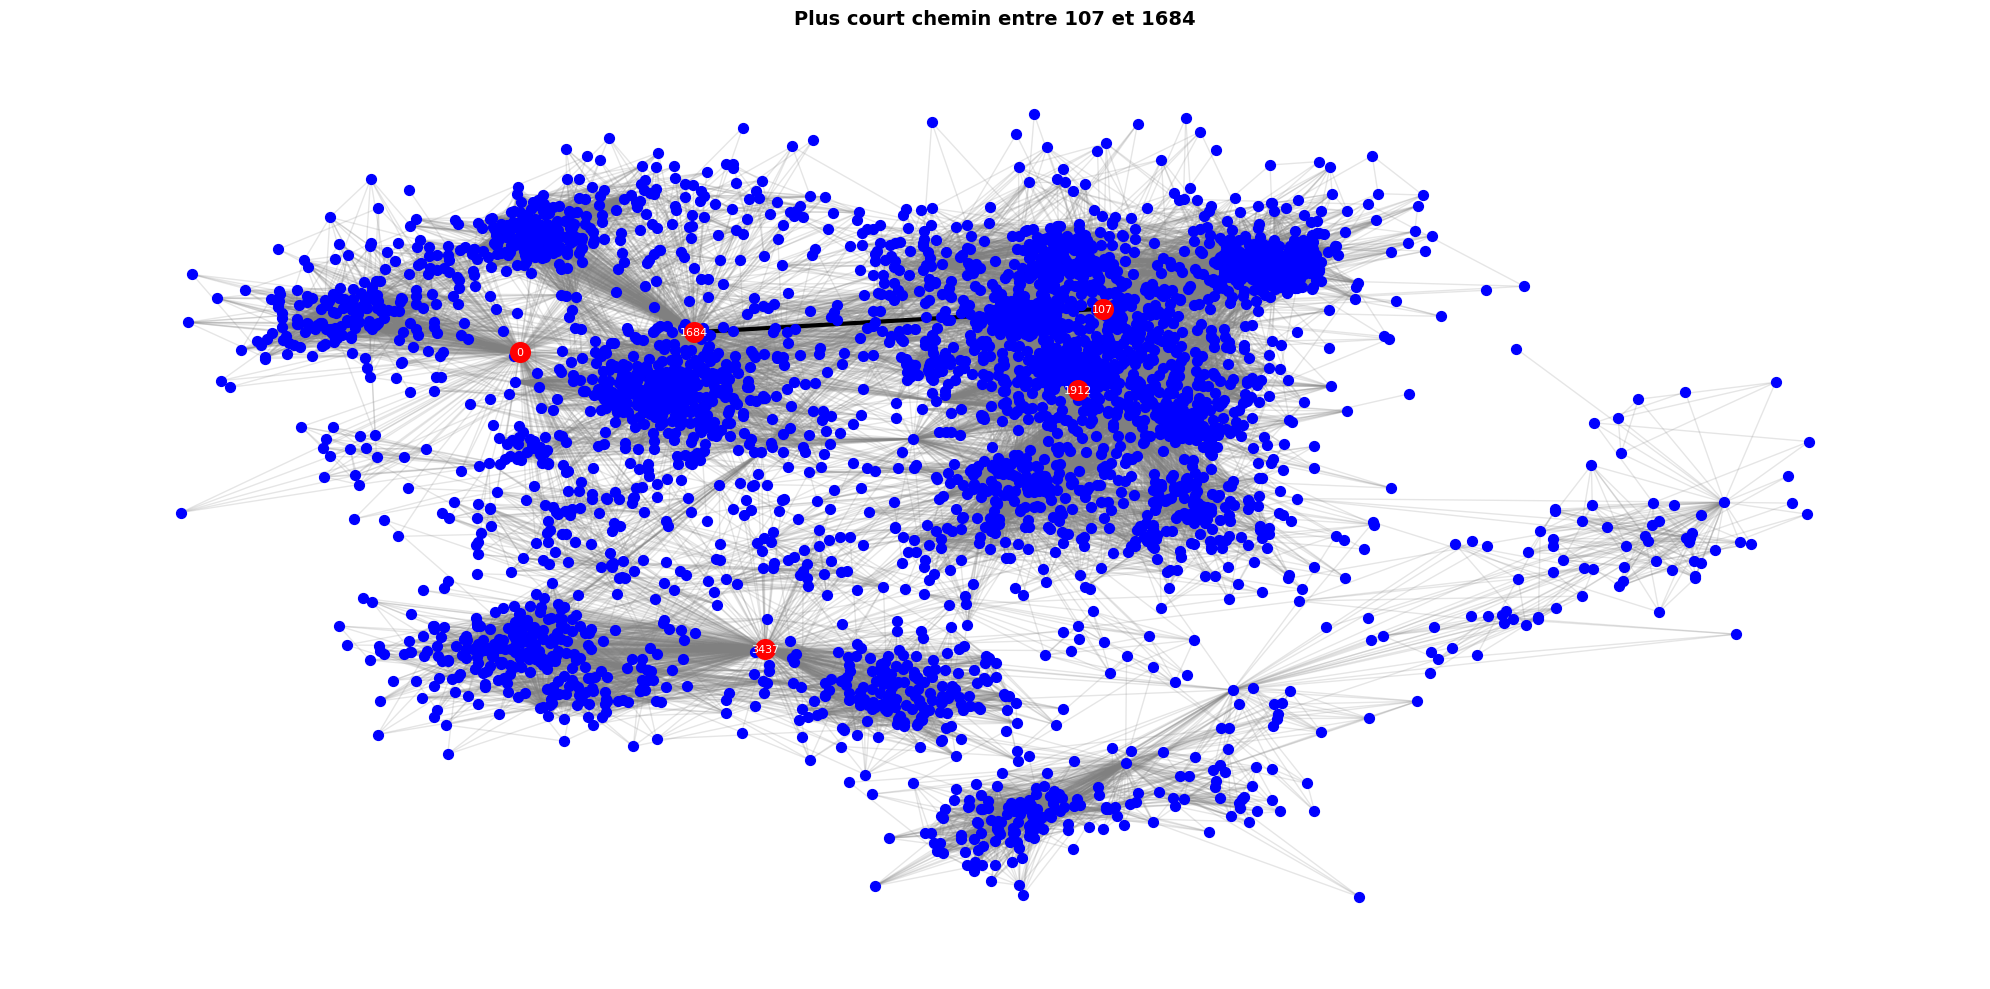

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Charger le graphe
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# ── définir les nœuds source et cible ───────────────────────────
source = 107    # nœud de départ (hub principal)
target = 1684   # nœud d'arrivée (2ème hub principal)

# ── calculer le plus court chemin entre source et target ─────────
path = nx.shortest_path(G, source, target)
# retourne la liste des nœuds formant le chemin le plus court

print(f"Plus court chemin entre {source} et {target} :")
print(path)
# affiche la séquence de nœuds à traverser

# ── extraire les nœuds intermédiaires (sans source ni target) ────
intermediate = path[1:-1]
# exclut le premier (source) et le dernier (target) nœud du chemin

# ── extraire les arêtes du chemin ────────────────────────────────
path_edges = list(zip(path[:-1], path[1:]))
# crée les paires de nœuds consécutifs formant les arêtes du chemin

# ── position des nœuds ───────────────────────────────────────────
pos = nx.spring_layout(G, seed=42)
# seed=42 pour une disposition reproductible

plt.figure(figsize=(20, 10))

# tous les nœuds en bleu
nx.draw_networkx_nodes(G, pos, node_color="blue", node_size=50)

# nœuds importants (top degré) en rouge
nx.draw_networkx_nodes(G, pos,
                       nodelist=[107, 1684, 1912, 3437, 0],
                       node_color="red", node_size=200)
# les 5 hubs principaux mis en évidence

# nœuds intermédiaires du chemin en vert
nx.draw_networkx_nodes(G, pos,
                       nodelist=intermediate,
                       node_color="green", node_size=150)
# les nœuds traversés entre 107 et 1684

# tous les liens en gris
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")

# arêtes du plus court chemin en noir et épaisses
nx.draw_networkx_edges(G, pos,
                       edgelist=path_edges,
                       edge_color="black", width=3)
# met en évidence le chemin entre 107 et 1684

# labels uniquement pour les nœuds importants
important = [107, 1684, 1912, 3437, 0] + intermediate
nx.draw_networkx_labels(G, pos,
                        labels={n: n for n in important},
                        font_size=8, font_color="white")
# affiche les identifiants des nœuds clés

plt.title(f"Plus court chemin entre {source} et {target}", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("plus_court_chemin.png", dpi=150, bbox_inches="tight")
plt.show()



Le chemin le plus court entre le nœud 107 et le nœud 1684 est **direct** , les deux hubs sont **directement connectés** entre eux sans aucun intermédiaire. Cela signifie que ces deux acteurs les plus influents du réseau se connaissent directement, ce qui est normale car ce sont les deux noeuds principaux du dataset Facebook avec le plus grand nombre de connexions. Leur lien direct renforce encore davantage leur position centrale et facilite une circulation d'information extrêmement rapide entre leurs deux communautés respectives.

In [ ]:
import networkx as nx

# Charger ton graphe (exemple avec fichier)
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# Récupérer TOUS les nœuds isolés
isolated_nodes = list(nx.isolates(G))

# Afficher la liste complète
print("Nœuds isolés :")
print(isolated_nodes)

# Afficher le nombre total
print("Nombre de nœuds isolés :", len(isolated_nodes))

Nœuds isolés :
[]
Nombre de nœuds isolés : 0


Ce bloc vérifie l'existence de nœuds isolés dans le réseau Facebook complet. Le résultat est une liste vide avec **0 nœud isolé**, ce qui signifie que chaque acteur du réseau possède au moins une connexion avec un autre acteur. C'est une propriété importante qui confirme que le réseau est **entièrement connecté** ,  aucun utilisateur n'est complètement coupé du reste, tout le monde participe à la structure relationnelle globale du réseau.

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# extraire la plus grande composante connexe (obligatoire)
largest_cc = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()

# calcul de la longueur moyenne des plus courts chemins
avg_path_length = nx.average_shortest_path_length(Gcc)

print("Longueur moyenne des plus courts chemins :", avg_path_length)

Longueur moyenne des plus courts chemins : 3.6925068496963913


Ce bloc calcule la longueur moyenne des plus courts chemins dans le réseau, c'est-à-dire le nombre moyen d'intermédiaires nécessaires pour relier deux acteurs quelconques. Une valeur de 3.69 signifie qu'en moyenne deux utilisateurs Facebook sont séparés par moins de 4 personnes.

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul du degré moyen
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Degré moyen :", avg_degree)

Degré moyen : 43.69101262688784


In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul du coefficient de clustering moyen (moyenne des nœuds)
avg_clustering = nx.average_clustering(G)

print("Coefficient local moyen (clustering moyen) :", avg_clustering)

Coefficient local moyen (clustering moyen) : 0.6055467186200862


Ce bloc calcule le coefficient de clustering moyen de l'ensemble du réseau. Une valeur de **0.606** signifie qu'en moyenne **60.6% des voisins d'un nœud sont également connectés entre eux** , c'est un indicateur très élevé qui confirme que le réseau Facebook est fortement structuré en **groupes soudés**. Autrement dit, les amis de mes amis sont très souvent aussi mes amis, ce qui est typique des réseaux sociaux réels où les individus se regroupent naturellement en communautés denses (famille, collègues, camarades de classe).

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# coefficient de clustering global (transitivity)
global_clustering = nx.transitivity(G)

print("Coefficient de clustering global :", global_clustering)

Coefficient de clustering global : 0.5191742775433075


Ce bloc calcule le coefficient de clustering global (aussi appelé transitivité) du réseau, c'est-à-dire la proportion de triangles fermés parmi tous les triplets de nœuds connectés. Une valeur de **0.519** signifie que **51.9% des triplets de nœuds forment des triangles complets** , si A connaît B et B connaît C, il y a une probabilité de 51.9% que A connaisse également C. Cette valeur est légèrement inférieure au clustering moyen local (0.606) car elle pondère tous les triangles de manière égale sans tenir compte de la taille des voisinages. Elle confirme néanmoins que le réseau Facebook est **fortement transitif** , les relations sociales ont une forte tendance à se fermer en triangles, ce qui reflète la nature communautaire et cloisonnée des amitiés sur les réseaux sociaux réels.

***PARTIE 4: DETECTION DE COMMUNITES***

Nombre de communautés détectées : 16

Taille des communautés :
  Communauté 0 → 350 nœuds
  Communauté 1 → 434 nœuds
  Communauté 2 → 19 nœuds
  Communauté 3 → 423 nœuds
  Communauté 4 → 535 nœuds
  Communauté 5 → 319 nœuds
  Communauté 6 → 118 nœuds
  Communauté 7 → 446 nœuds
  Communauté 8 → 19 nœuds
  Communauté 9 → 73 nœuds
  Communauté 10 → 237 nœuds
  Communauté 11 → 25 nœuds
  Communauté 12 → 61 nœuds
  Communauté 13 → 206 nœuds
  Communauté 14 → 548 nœuds
  Communauté 15 → 226 nœuds


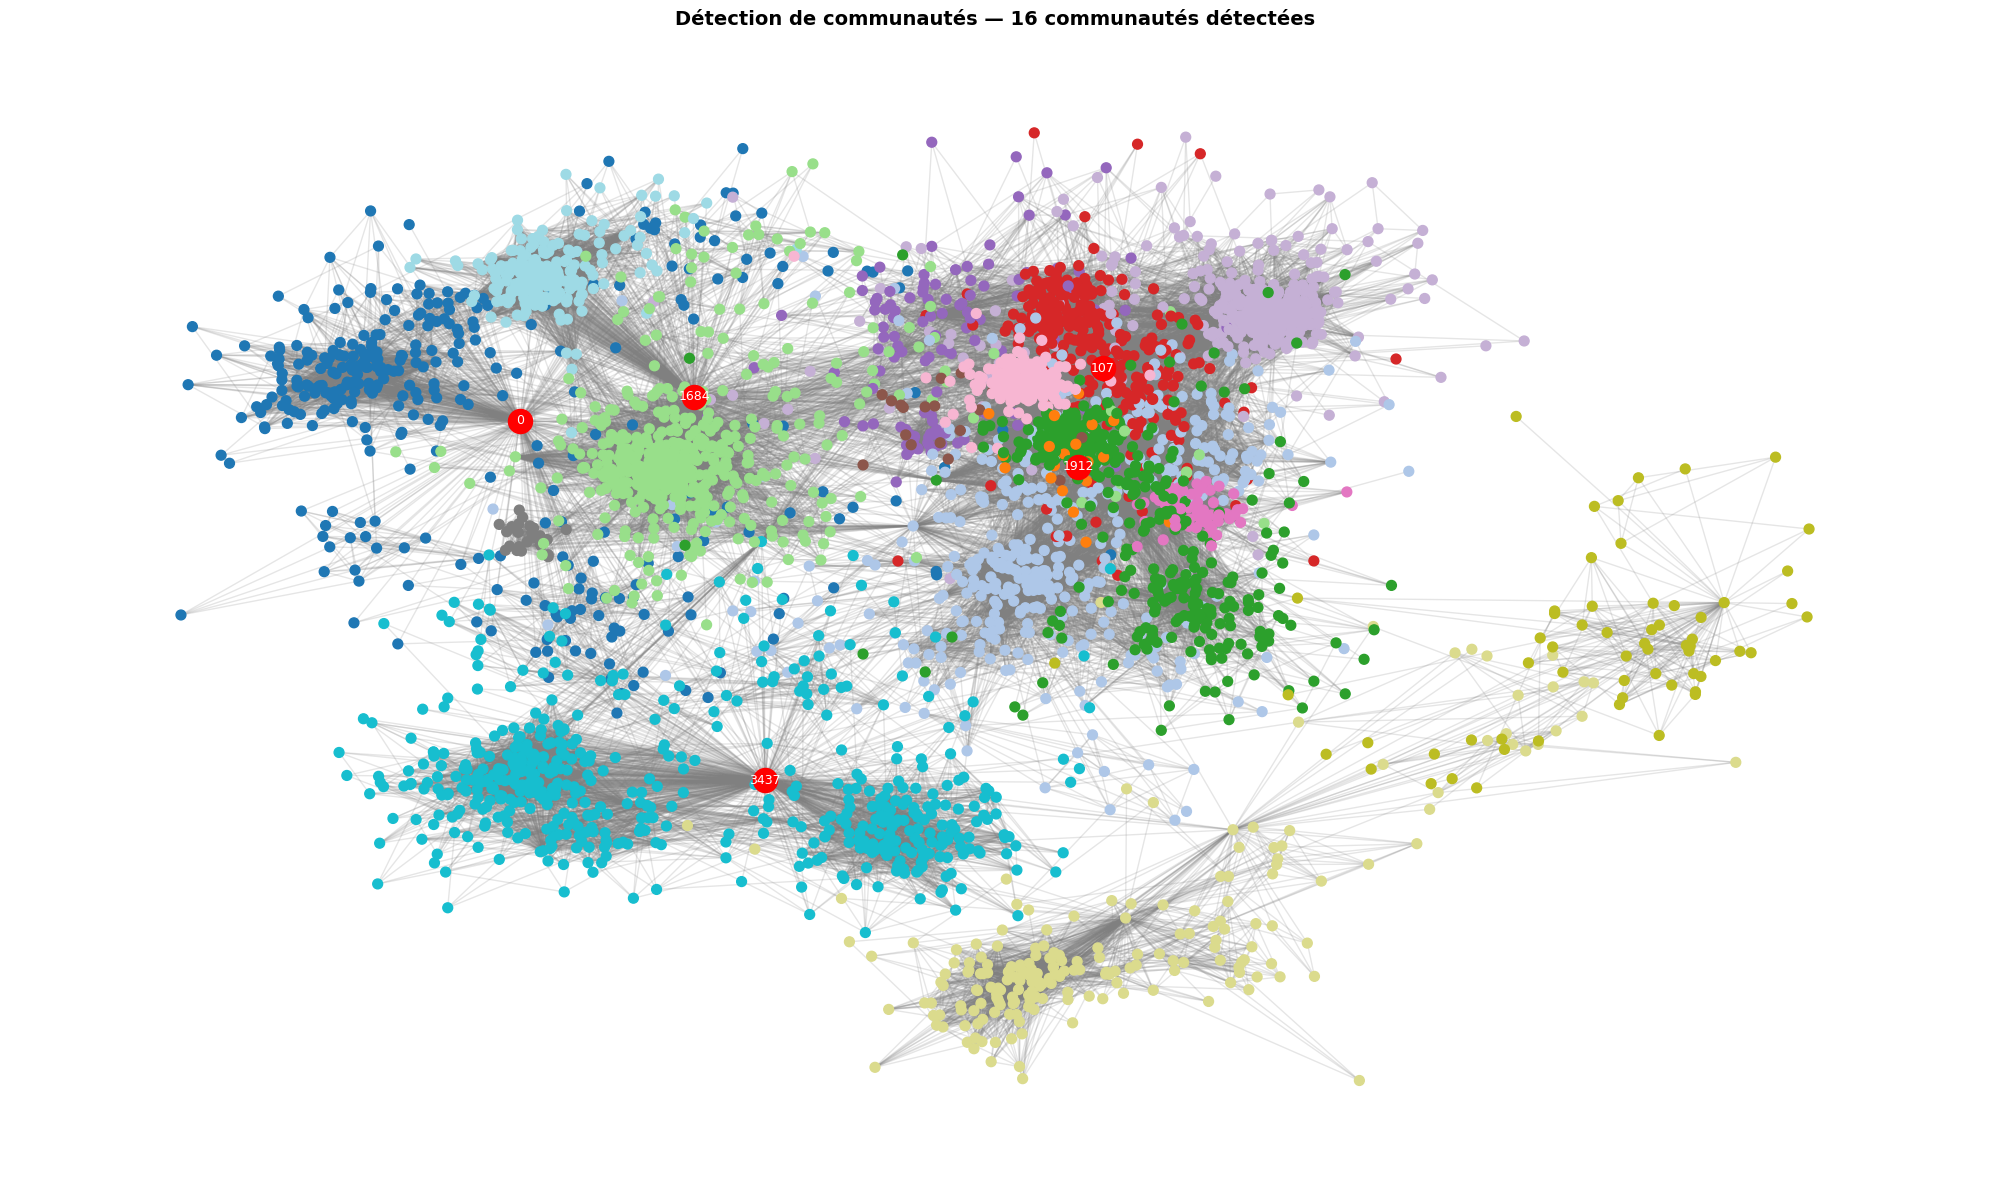


Nœud 107 appartient à la communauté : 7
Taille de sa communauté : 446 nœuds


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# ── charger le graphe ────────────────────────────────────────────
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)
# charge le réseau Facebook complet

# ── détection de communautés (algorithme de Louvain) ─────────────
from community import best_partition
# importe l'algorithme de Louvain (pip install python-louvain)

partition = best_partition(G)
# détecte automatiquement les communautés
# retourne un dictionnaire {nœud: numéro_communauté}

# ── statistiques sur les communautés ─────────────────────────────
nb_communautes = max(partition.values()) + 1
# nombre total de communautés détectées

print(f"Nombre de communautés détectées : {nb_communautes}")

# taille de chaque communauté
sizes = Counter(partition.values())
# compte le nombre de nœuds par communauté

print("\nTaille des communautés :")
for comm, size in sorted(sizes.items()):
    print(f"  Communauté {comm} → {size} nœuds")

# ── visualisation ────────────────────────────────────────────────
pos = nx.spring_layout(G, seed=42)
# disposition des nœuds reproductible

plt.figure(figsize=(20, 12))

# couleur de chaque nœud selon sa communauté
colors = [partition[n] for n in G.nodes()]
# assigne un numéro de communauté à chaque nœud

nx.draw_networkx_nodes(G, pos,
                       node_color=colors,
                       cmap=plt.cm.tab20,
                       # palette de 20 couleurs distinctes
                       node_size=50)

nx.draw_networkx_edges(G, pos,
                       alpha=0.2,
                       edge_color="gray")
# liens en gris transparent

# met en évidence les hubs principaux
hubs = [107, 1684, 1912, 3437, 0]
nx.draw_networkx_nodes(G, pos,
                       nodelist=hubs,
                       node_color="red",
                       node_size=300)
# hubs en rouge pour les distinguer des communautés

nx.draw_networkx_labels(G, pos,
                        labels={n: n for n in hubs},
                        font_size=9,
                        font_color="white")
# affiche les labels uniquement pour les hubs

plt.title(f"Détection de communautés — {nb_communautes} communautés détectées",
          fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("communautes.png", dpi=150, bbox_inches="tight")
plt.show()

# ── communauté du nœud 107 ───────────────────────────────────────
comm_107 = partition[107]
# récupère le numéro de communauté du nœud 107

membres_107 = [n for n, c in partition.items() if c == comm_107]
# liste tous les membres de la même communauté que 107

print(f"\nNœud 107 appartient à la communauté : {comm_107}")
print(f"Taille de sa communauté : {len(membres_107)} nœuds")

Ce bloc applique l'algorithme de Louvain sur le réseau Facebook et détecte **16 communautés** regroupant les 4 039 nœuds. Les résultats révèlent une structure communautaire très hétérogène , les tailles varient de **19 nœuds** (communautés 2 et 8, très petites et probablement des cliques fermées) à **548 nœuds** (communauté 14, la plus grande). Les communautés 4 et 14 sont les plus importantes avec respectivement 535 et 548 membres, représentant chacune environ **13% du réseau total**.

Le nœud 107, hub principal du réseau, appartient à la **communauté 7** qui regroupe **446 nœuds** , c'est la 3ème plus grande communauté. Sa présence dans une communauté de cette taille confirme son rôle de fédérateur d'un large groupe social. Les petites communautés (2, 8, 11, 12) correspondent probablement à des cercles d'amis très fermés et spécialisés, tandis que les grandes communautés reflètent des groupes sociaux plus ouverts et diversifiés comme des réseaux universitaires ou professionnels.

L'algorithme de Louvain est une méthode de détection de communautés dans les réseaux. Il cherche à regrouper les nœuds en communautés de manière à maximiser la modularité du réseau , c'est-à-dire trouver des groupes où les nœuds sont plus connectés entre eux qu'avec le reste du réseau.

***PARTIE 5: ANALYSE DE SIMILARITE***

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# calcul des coefficients de Jaccard sur les arêtes
jaccard = list(nx.jaccard_coefficient(G))

# afficher quelques résultats
print("Exemples de similarité de Jaccard :")
for u, v, p in jaccard[:10]:
    print(f"({u}, {v}) → Jaccard = {p:.5f}")

Exemples de similarité de Jaccard :
(0, 348) → Jaccard = 0.00699
(0, 349) → Jaccard = 0.00000
(0, 350) → Jaccard = 0.00000
(0, 351) → Jaccard = 0.00285
(0, 352) → Jaccard = 0.00000
(0, 353) → Jaccard = 0.00223
(0, 354) → Jaccard = 0.00000
(0, 355) → Jaccard = 0.00000
(0, 356) → Jaccard = 0.00000
(0, 357) → Jaccard = 0.00000


Ce bloc calcule pour chaque paire de nœuds la proportion de voisins qu'ils partagent en commun. Les valeurs proches de **0.000** indiquent que les nœuds comparés avec le nœud 0 ont très peu ou aucun ami en commun, ce qui est logique car le nœud 0 est un hub qui concentre des connexions provenant de communautés très différentes. Seul le nœud 348 partage quelques voisins communs avec le nœud 0 (0.007), mais cela reste très faible , confirmant que dans ce réseau, les hubs très connectés ont des voisins qui ne se connaissent généralement pas entre eux.

In [ ]:

top_jaccard = sorted(jaccard, key=lambda x: x[2], reverse=True)

print("Top 10 des paires les plus similaires :")
for u, v, p in top_jaccard[:10]:
    print(f"({u}, {v}) → Jaccard = {p:.5f}")

Top 10 des paires les plus similaires :
(11, 12) → Jaccard = 1.00000
(11, 15) → Jaccard = 1.00000
(11, 18) → Jaccard = 1.00000
(11, 37) → Jaccard = 1.00000
(11, 43) → Jaccard = 1.00000
(11, 74) → Jaccard = 1.00000
(11, 114) → Jaccard = 1.00000
(11, 209) → Jaccard = 1.00000
(11, 210) → Jaccard = 1.00000
(11, 215) → Jaccard = 1.00000


Ce bloc trie toutes les paires par similarité de Jaccard décroissante et affiche les 10 plus similaires. Ces 10 paires ont toutes un Jaccard de **1.000**, ce qui signifie qu'elles partagent **exactement les mêmes voisins** ,  100% de leurs connexions sont identiques. On remarque que le nœud 11 est impliqué dans toutes ces paires, ce qui indique qu'il appartient à une **clique très fermée** où tous les membres ont exactement le même cercle d'amis. Ces acteurs sont structurellement **interchangeables** dans le réseau , ils occupent la même position relationnelle et jouent le même rôle social, typique des petits groupes très soudés comme une famille ou un groupe de camarades de classe.

- La similarité de Jaccard mesure le degré de ressemblance entre deux nœuds en comparant leurs voisinages respectifs.

In [ ]:
import networkx as nx

# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# fonction voisins communs
def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)) & set(G.neighbors(v)))

# calcul sur quelques arêtes
vc_results = []
for u, v in list(G.edges())[:1000]:
    vc_results.append((u, v, common_neighbors(G, u, v)))

# affichage exemples
print("Exemples de voisins communs :")
for u, v, p in vc_results[:10]:
    print(f"({u}, {v}) → VC = {p}")

Exemples de voisins communs :
(0, 1) → VC = 16
(0, 2) → VC = 9
(0, 3) → VC = 16
(0, 4) → VC = 9
(0, 5) → VC = 12
(0, 6) → VC = 5
(0, 7) → VC = 19
(0, 8) → VC = 7
(0, 9) → VC = 56
(0, 10) → VC = 9


Ce bloc calcule le nombre de voisins communs entre les paires de nœuds directement connectés. Le nœud 0 partage entre **5 et 56 voisins communs** avec ses voisins directs , la paire (0, 9) est la plus forte avec **56 amis en commun**, indiquant une relation sociale très renforcée entre ces deux acteurs. Les autres paires oscillent entre 5 et 19 voisins communs, ce qui confirme que les connexions du nœud 0 ne sont pas aléatoires mais s'inscrivent dans des cercles sociaux partiellement partagés. Plus le nombre de voisins communs est élevé, plus la relation entre deux acteurs est **socialement ancrée** et moins elle risque de disparaître.

In [ ]:
top_vc = sorted(vc_results, key=lambda x: x[2], reverse=True)

print("Top 10 des paires (voisins communs) :")
for u, v, p in top_vc[:10]:
    print(f"({u}, {v}) → VC = {p}")

Top 10 des paires (voisins communs) :
(0, 56) → VC = 77
(0, 67) → VC = 75
(0, 271) → VC = 72
(0, 322) → VC = 71
(0, 25) → VC = 68
(0, 26) → VC = 67
(0, 21) → VC = 64
(0, 252) → VC = 64
(0, 277) → VC = 64
(0, 122) → VC = 62


Ce bloc affiche les 10 paires avec le plus grand nombre de voisins communs. Le nœud 0 domine toutes les paires avec des valeurs allant de **62 à 77 voisins communs**. La paire **(0, 56)** est la plus forte avec 77 amis en commun , ces deux acteurs sont donc extrêmement proches socialement et partagent un très grand cercle d'amis communs. Le fait que le nœud 0 apparaisse dans toutes les paires du top 10 confirme qu'il est au cœur d'une communauté très dense où les membres se connaissent massivement entre eux, malgré son faible coefficient de clustering local observé précédemment.

***PARTIE 6: PREDICTION DES LIENS***

In [ ]:
# charger le graphe Facebook Combined
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)
# tri décroissant
top_jaccard = sorted(jaccard, key=lambda x: x[2], reverse=True)

print(" Top 10 prédictions (Jaccard) :")
for u, v, score in top_jaccard[:10]:
    print(f"({u}, {v}) → score = {score:.5f}")

 Top 10 prédictions (Jaccard) :
(11, 12) → score = 1.00000
(11, 15) → score = 1.00000
(11, 18) → score = 1.00000
(11, 37) → score = 1.00000
(11, 43) → score = 1.00000
(11, 74) → score = 1.00000
(11, 114) → score = 1.00000
(11, 209) → score = 1.00000
(11, 210) → score = 1.00000
(11, 215) → score = 1.00000


Ce bloc utilise la similarité de Jaccard comme prédicteur de liens futurs dans le réseau. Les 10 paires affichées ont toutes un score de 1.000, ce qui signifie qu'elles partagent exactement les mêmes voisins , ce sont les paires les plus susceptibles de se connecter prochainement si elles ne sont pas déjà liées. Le nœud 11 apparaît dans toutes les paires, indiquant qu'il est au centre d'un groupe très cohésif où tous les membres ont le même cercle social.

In [ ]:
# score = nombre de voisins communs
def common_neighbors_score(G, u, v):
    return len(set(G.neighbors(u)) & set(G.neighbors(v)))

# calcul des scores
scores = []
for u, v in list(candidates)[:5000]:  # limite pour performance
    score = common_neighbors_score(G, u, v)
    scores.append((u, v, score))

# tri décroissant
top_predictions = sorted(scores, key=lambda x: x[2], reverse=True)

print(" Top 10 prédictions (amis d'amis) :")
for u, v, score in top_predictions[:10]:
    print(f"{u} -- {v} → amis communs = {score}")

 Top 10 prédictions (amis d'amis) :
2347 -- 2654 → amis communs = 137
2115 -- 2630 → amis communs = 118
1925 -- 2433 → amis communs = 103
2492 -- 2563 → amis communs = 102
2261 -- 2561 → amis communs = 100
2237 -- 2307 → amis communs = 94
2404 -- 2489 → amis communs = 86
1267 -- 1551 → amis communs = 86
2060 -- 2638 → amis communs = 85
1833 -- 1868 → amis communs = 82


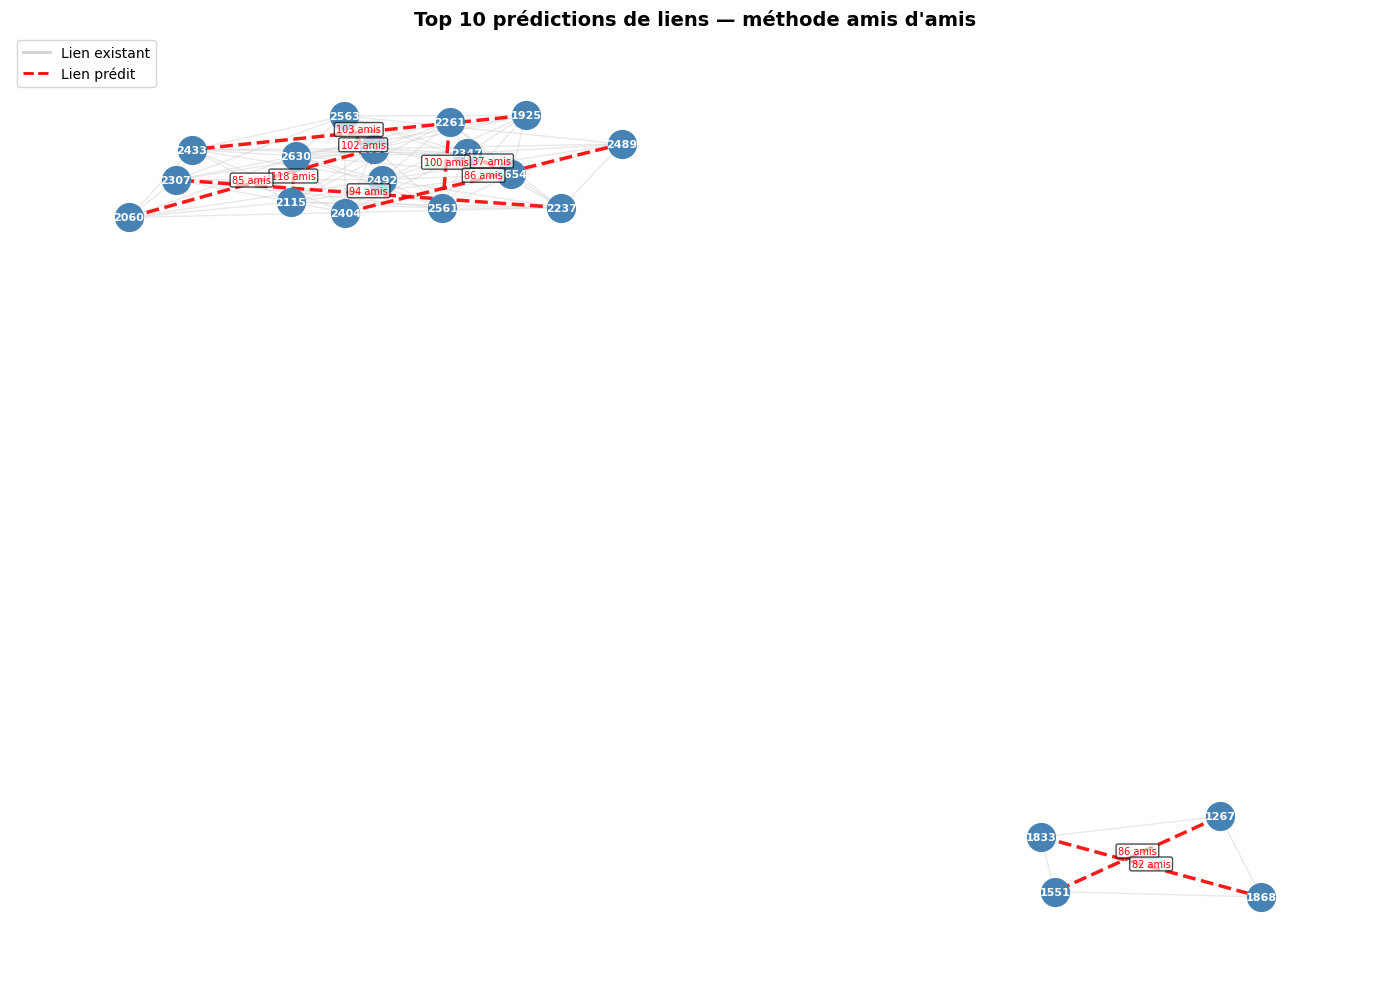

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# ── charger le graphe ────────────────────────────────────────────
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# ── top 10 prédictions de liens ──────────────────────────────────
predicted_links = [
    (2347, 2654, 137),
    (2115, 2630, 118),
    (1925, 2433, 103),
    (2492, 2563, 102),
    (2261, 2561, 100),
    (2237, 2307,  94),
    (2404, 2489,  86),
    (1267, 1551,  86),
    (2060, 2638,  85),
    (1833, 1868,  82),
]
# liste des 10 paires de nœuds avec leur nombre d'amis communs

# ── construire un sous-graphe avec les nœuds concernés ───────────
nodes_in_pred = set()
for u, v, _ in predicted_links:
    nodes_in_pred.add(u)
    nodes_in_pred.add(v)
# récupère tous les nœuds impliqués dans les prédictions

subG = G.subgraph(nodes_in_pred).copy()
# extrait le sous-graphe contenant uniquement ces nœuds
# et leurs liens existants dans le réseau original

# ── position des nœuds ───────────────────────────────────────────
pos = nx.spring_layout(subG, seed=42)
# disposition reproductible des nœuds

plt.figure(figsize=(14, 10))

# ── dessiner les liens existants en gris ─────────────────────────
nx.draw_networkx_edges(subG, pos,
                       edge_color="lightgray",
                       width=1,
                       alpha=0.5)
# liens déjà existants entre ces nœuds

# ── dessiner les liens prédits en rouge pointillé ────────────────
predicted_edges = [(u, v) for u, v, _ in predicted_links]
# liste des arêtes prédites

nx.draw_networkx_edges(subG, pos,
                       edgelist=predicted_edges,
                       edge_color="red",
                       width=2.5,
                       style="dashed",
                       alpha=0.9)
# liens prédits en rouge pointillé — n'existent pas encore

# ── dessiner les nœuds ───────────────────────────────────────────
nx.draw_networkx_nodes(subG, pos,
                       node_color="steelblue",
                       node_size=400)
# tous les nœuds en bleu

# ── labels des nœuds ─────────────────────────────────────────────
nx.draw_networkx_labels(subG, pos,
                        font_size=8,
                        font_color="white",
                        font_weight="bold")
# affiche les identifiants de chaque nœud

# ── annotation des scores sur les liens prédits ──────────────────
for u, v, score in predicted_links:
    if u in pos and v in pos:
        # calcule le point milieu entre u et v
        mid_x = (pos[u][0] + pos[v][0]) / 2
        mid_y = (pos[u][1] + pos[v][1]) / 2
        plt.annotate(f"{score} amis",
                     xy=(mid_x, mid_y),
                     fontsize=7,
                     color="red",
                     ha="center",
                     bbox=dict(boxstyle="round,pad=0.2",
                               fc="white", alpha=0.7))
        # affiche le nombre d'amis communs au milieu de chaque lien prédit

# ── légende manuelle ─────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="lightgray", linewidth=2, label="Lien existant"),
    Line2D([0], [0], color="red", linewidth=2,
           linestyle="dashed", label="Lien prédit"),
]
plt.legend(handles=legend_elements, loc="upper left", fontsize=10)
# légende pour distinguer liens existants et prédits

plt.title("Top 10 prédictions de liens — méthode amis d'amis",
          fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("predictions_liens.png", dpi=150, bbox_inches="tight")
plt.show()

Ce bloc prédit les liens les plus probables dans le réseau en se basant sur le nombre d'amis communs entre des paires non encore connectées. La paire **(2347, 2654)** domine avec **137 amis communs** , ces deux personnes ne se connaissent pas encore directement mais partagent 137 amis en commun, ce qui rend leur future connexion extrêmement probable. Les autres paires du top 10 affichent entre **82 et 118 amis communs**, confirmant qu'elles appartiennent toutes à des communautés très denses où la quasi-totalité des membres se connaissent déjà. En ARS, ce résultat constitue la base du système de recommandation **"personnes que vous connaissez peut-être"** , plus deux acteurs ont d'amis communs sans être connectés, plus la recommandation de les mettre en relation est pertinente et fiable.